In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#import sklearn built-in dataset

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [18]:
#generate the dataset
X, y = make_moons(n_samples=300,noise=0.08,random_state=42
)

In [ ]:
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

df["Actual_Class"] = y

df.head()

,Feature1,Feature2,Actual_Class
0,0.658801,-0.355963,1
1,1.986302,-0.133490,1
2,-0.111623,0.455081,1
3,0.905008,0.266798,0
4,1.181619,-0.494965,1


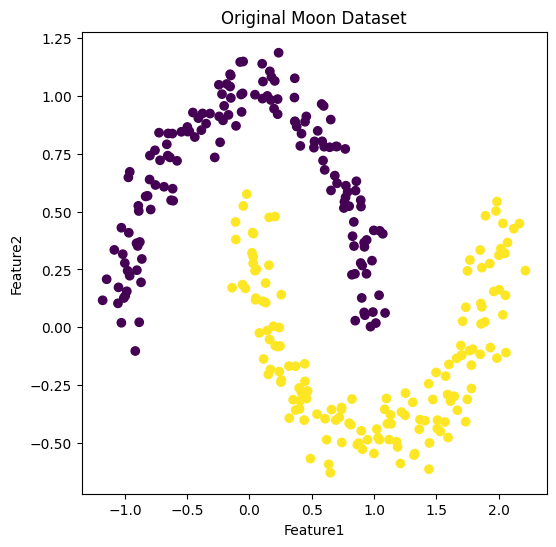

In [19]:
#Visualize the Dataset
plt.figure(figsize=(6,6))

plt.scatter(X[:,0],X[:,1],c=y,cmap="viridis")

plt.title("Original Moon Dataset")

plt.xlabel("Feature1")

plt.ylabel("Feature2")

plt.show()

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
#Train the DBSCAN Model
dbscan = DBSCAN(
    eps=0.25,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

In [22]:
df["Cluster"] = clusters

df.head()

,Feature1,Feature2,Actual_Class,Cluster
0,0.658801,-0.355963,1,0
1,1.986302,-0.133490,1,0
2,-0.111623,0.455081,1,0
3,0.905008,0.266798,0,1
4,1.181619,-0.494965,1,0


In [23]:
print("Cluster Labels")

print(df["Cluster"].value_counts())

Cluster Labels
Cluster
 0    149
 1    149
-1      2
Name: count, dtype: int64


In [24]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print("Number of Clusters:", n_clusters)

Number of Clusters: 2


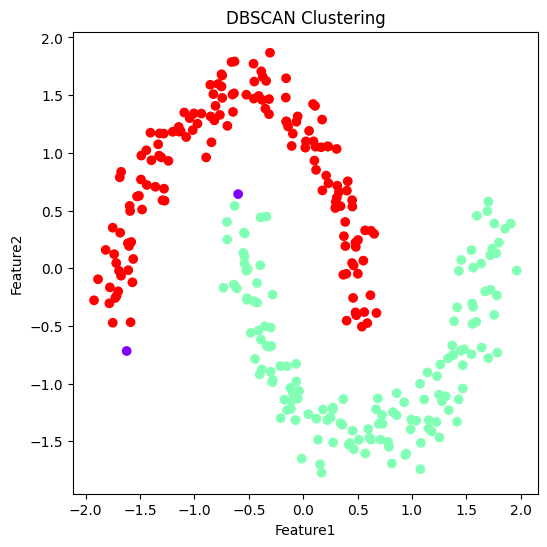

In [25]:
plt.figure(figsize=(6,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap="rainbow"
)

plt.title("DBSCAN Clustering")

plt.xlabel("Feature1")

plt.ylabel("Feature2")

plt.show()

In [26]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.19231757084675688
